 1. Data Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

date_range = pd.date_range(start="2025-01-01", periods=8760, freq="h")
df = pd.DataFrame({"timestamp": date_range})
df.set_index("timestamp", inplace=True)

df["hour"]        = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"]       = df.index.month
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)

annual_cycle = 3 * np.sin(2 * np.pi * df.index.dayofyear / 365)
daily_cycle  = 5 * np.sin(2 * np.pi * df["hour"] / 24)
temperature  = 28 + annual_cycle + daily_cycle + np.random.normal(0, 1.5, 8760)
df["temperature"] = temperature

humidity = 75 - 0.5 * temperature + np.random.normal(0, 3, 8760)
df["humidity"] = humidity

df["wind_speed"] = 5 + 1.5 * np.sin(2 * np.pi * df.index.dayofyear / 365) + np.random.normal(0, 1, 8760)

occupancy = []
for ts in df.index:
    if ts.weekday() < 5:
        if 8 <= ts.hour <= 18:
            occupancy.append(np.random.normal(0.85, 0.05))
        else:
            occupancy.append(np.random.normal(0.3, 0.05))
    else:
        occupancy.append(np.random.normal(0.2, 0.05))
df["occupancy"] = np.clip(occupancy, 0, 1)

df["exam_week"] = 0
exam_weeks = np.random.choice(range(1, 52), 3, replace=False)
for week in exam_weeks:
    df.loc[df.index.isocalendar().week == week, "exam_week"] = 1

base_load = 200
energy = []
for i in range(len(df)):
    temp  = df["temperature"].iloc[i]
    occ   = df["occupancy"].iloc[i]
    hum   = df["humidity"].iloc[i]
    exam  = df["exam_week"].iloc[i]
    prev_energy = base_load if i == 0 else energy[i-1]
    value = (
        base_load
        + 3 * temp
        + 50 * occ
        + 0.5 * hum
        + 0.8 * prev_energy * 0.05
        + 0.02 * (temp ** 2)
        + 20 * exam
        + np.random.normal(0, 10)
    )
    energy.append(value)

df["energy_kwh"] = energy
df.head()

,hour,day_of_week,month,is_weekend,temperature,humidity,wind_speed,occupancy,exam_week,energy_kwh
timestamp,,,,,,,,,,
2025-01-01 00:00:00,0,2,1,0,28.796711,63.515881,5.146170,0.354031,0,368.380102
2025-01-01 01:00:00,1,2,1,0,29.138339,56.545055,5.746277,0.338937,0,362.824265
2025-01-01 02:00:00,2,2,1,0,31.523173,55.675754,4.167234,0.321925,0,352.118411
2025-01-01 03:00:00,3,2,1,0,33.871719,59.800870,6.721336,0.331894,0,384.223249
2025-01-01 04:00:00,4,2,1,0,32.030537,58.791719,2.978653,0.309009,0,381.045608


2. Feature Engineering
Lag features, rolling statistics, and cyclical encodings

In [2]:
# Lag features
df["lag_1"]   = df["energy_kwh"].shift(1)
df["lag_24"]  = df["energy_kwh"].shift(24)
df["lag_168"] = df["energy_kwh"].shift(168)

# Rolling statistics (shifted to avoid data leakage)
df["rolling_mean_24"]  = df["energy_kwh"].shift(1).rolling(window=24).mean()
df["rolling_std_24"]   = df["energy_kwh"].shift(1).rolling(window=24).std()
df["rolling_mean_168"] = df["energy_kwh"].shift(1).rolling(window=168).mean()

# Cyclical encoding of hour and day
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["day_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Drop NaN rows created by lag/rolling windows
df = df.dropna()
print(f"Dataset shape after dropna: {df.shape}")
df.head()

Dataset shape after dropna: (8592, 20)


,hour,day_of_week,month,is_weekend,temperature,humidity,wind_speed,occupancy,exam_week,energy_kwh,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,hour_sin,hour_cos,day_sin,day_cos
timestamp,,,,,,,,,,,,,,,,,,,,
2025-01-08 00:00:00,0,2,1,0,28.043754,57.965109,3.125636,0.298606,0,366.095270,369.923437,364.914830,368.380102,374.776027,21.983855,368.572946,0.000000,1.000000,0.974928,-0.222521
2025-01-08 01:00:00,1,2,1,0,28.575327,61.092810,4.410743,0.245346,0,361.847537,366.095270,371.288952,362.824265,374.825212,21.962143,368.559346,0.258819,0.965926,0.974928,-0.222521
2025-01-08 02:00:00,2,2,1,0,29.577565,59.112193,6.253095,0.280607,0,358.961686,361.847537,369.171508,352.118411,374.431820,22.112285,368.553532,0.500000,0.866025,0.974928,-0.222521
2025-01-08 03:00:00,3,2,1,0,30.723655,60.168459,5.149832,0.297600,0,354.438109,358.961686,356.717200,384.223249,374.006411,22.315166,368.594266,0.707107,0.707107,0.974928,-0.222521
2025-01-08 04:00:00,4,2,1,0,32.626311,58.753896,6.368899,0.332447,0,378.446051,354.438109,381.509171,381.045608,373.911449,22.396640,368.416973,0.866025,0.500000,0.974928,-0.222521


3. Exploratory Data Analysis (EDA)

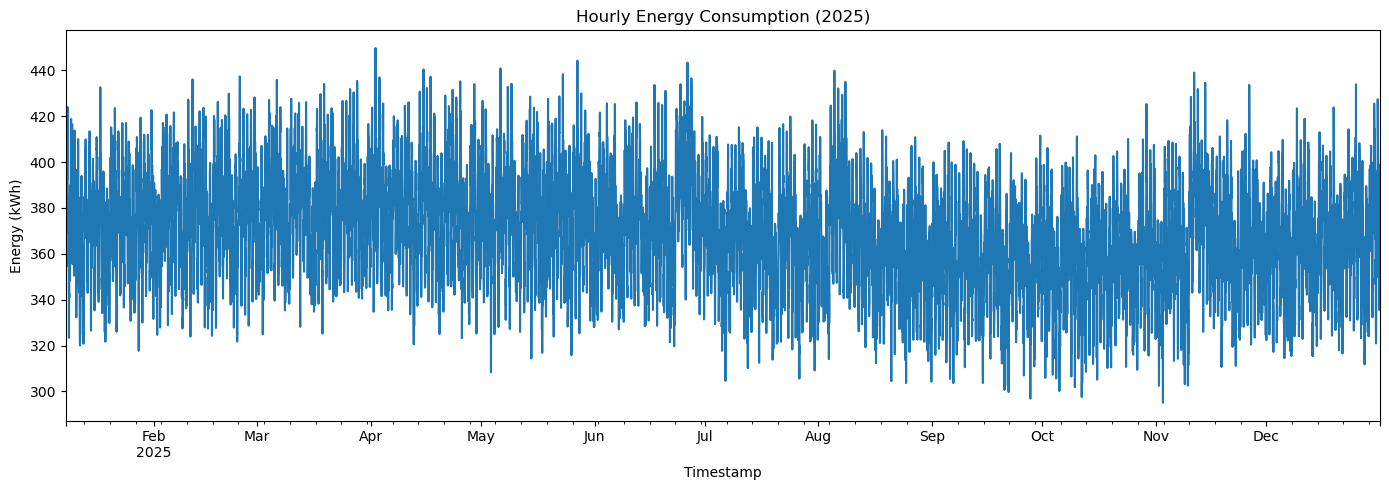

In [3]:
# 3.1 Full-year energy consumption plot
df["energy_kwh"].plot(figsize=(14, 5), title="Hourly Energy Consumption (2025)")
plt.ylabel("Energy (kWh)")
plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

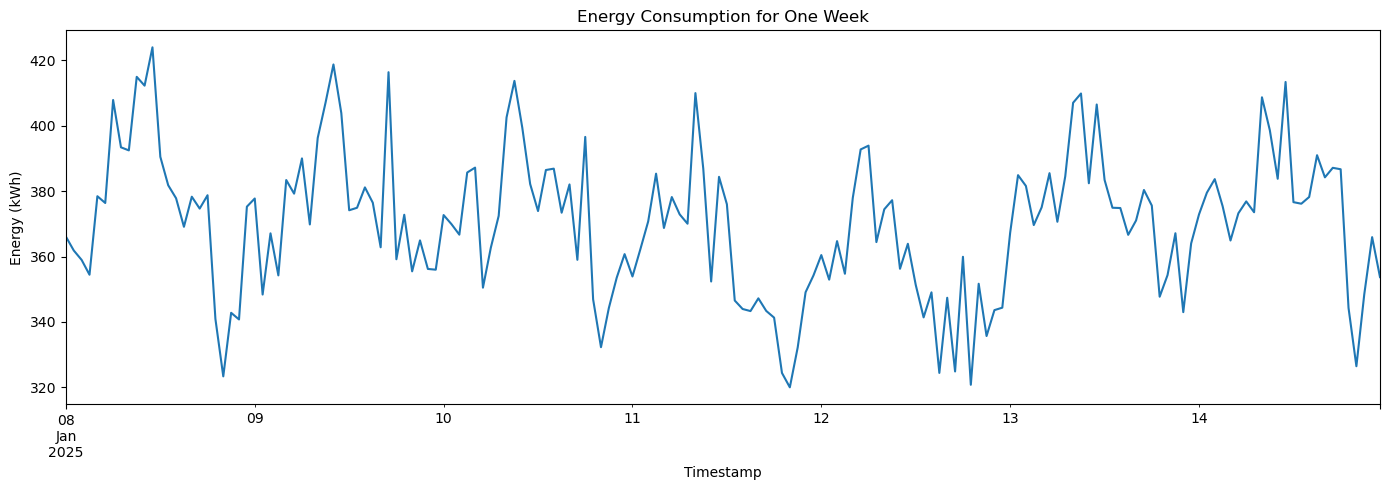

In [4]:
# 3.2 One-week zoom
df["energy_kwh"].iloc[:168].plot(figsize=(14, 5), title="Energy Consumption for One Week")
plt.ylabel("Energy (kWh)")
plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

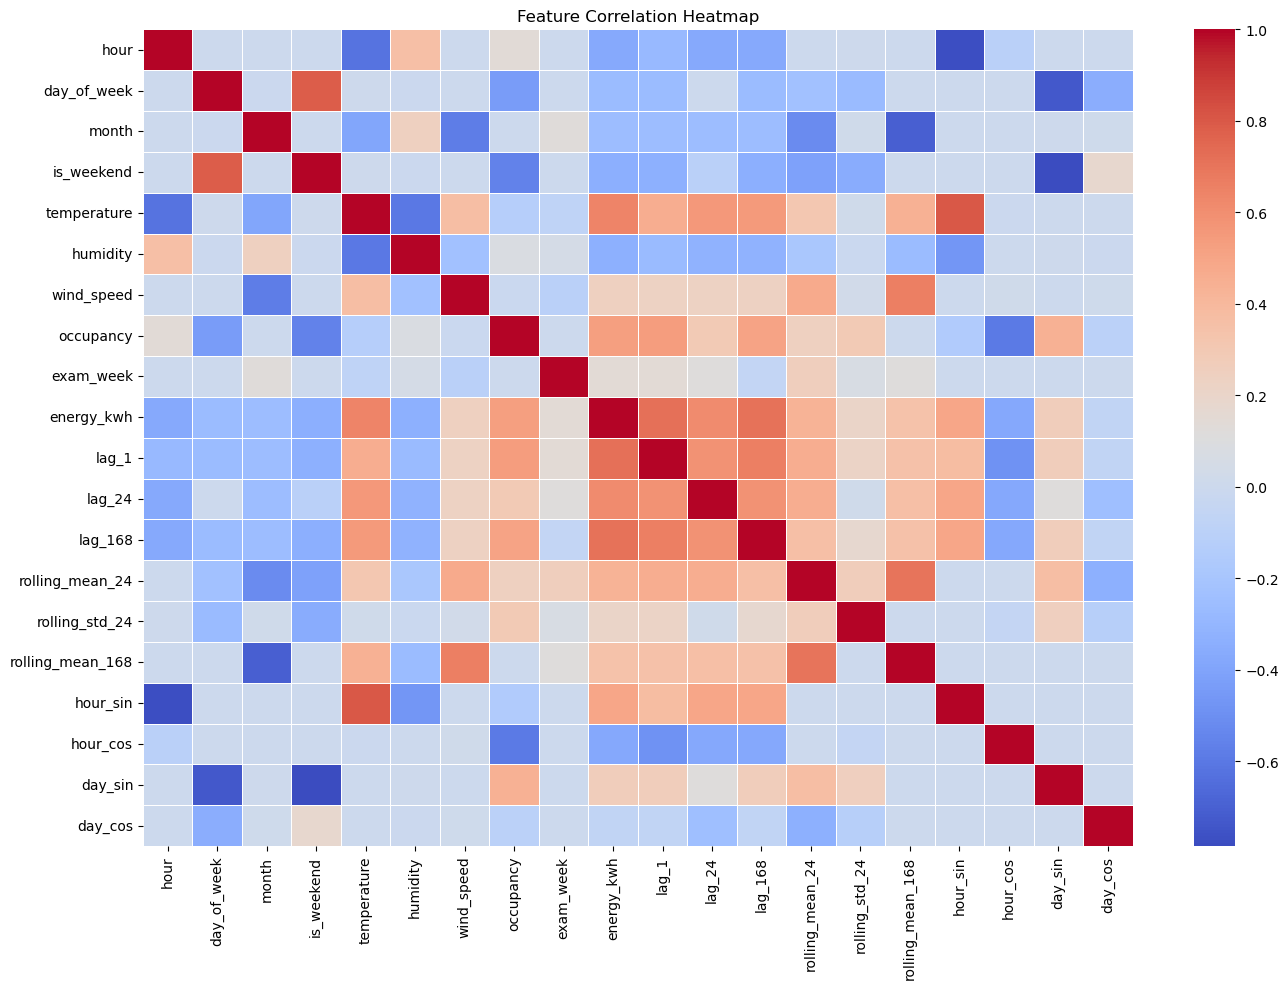

In [5]:
# 3.3 Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

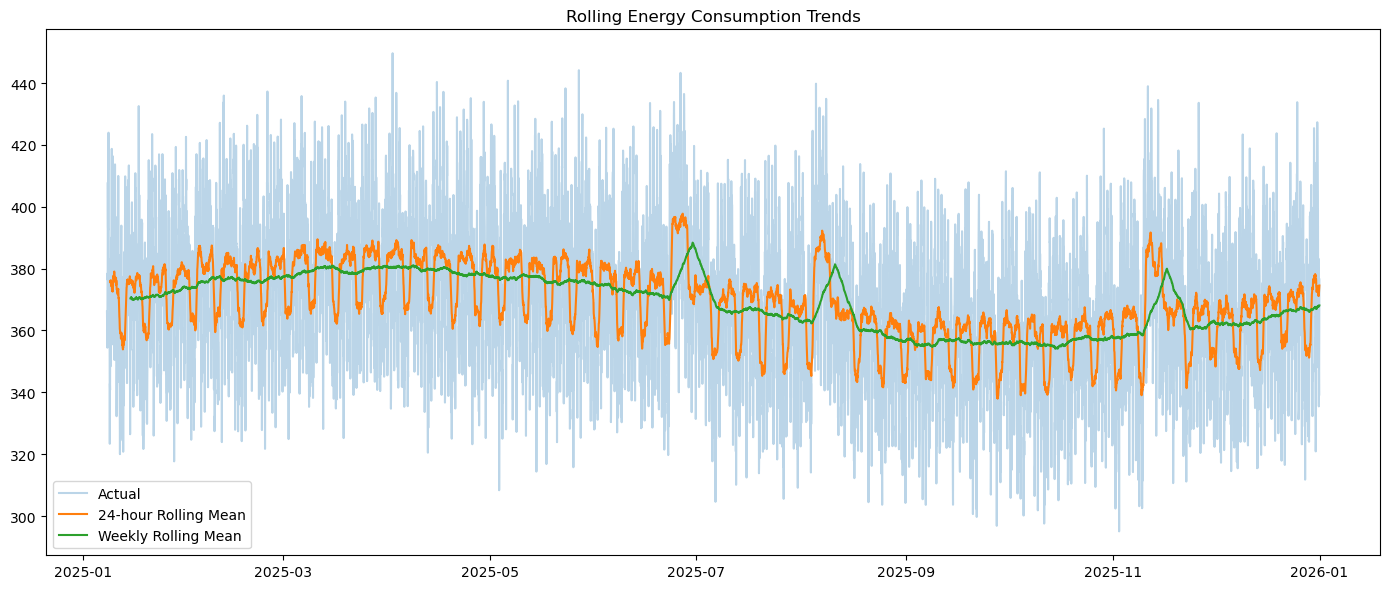

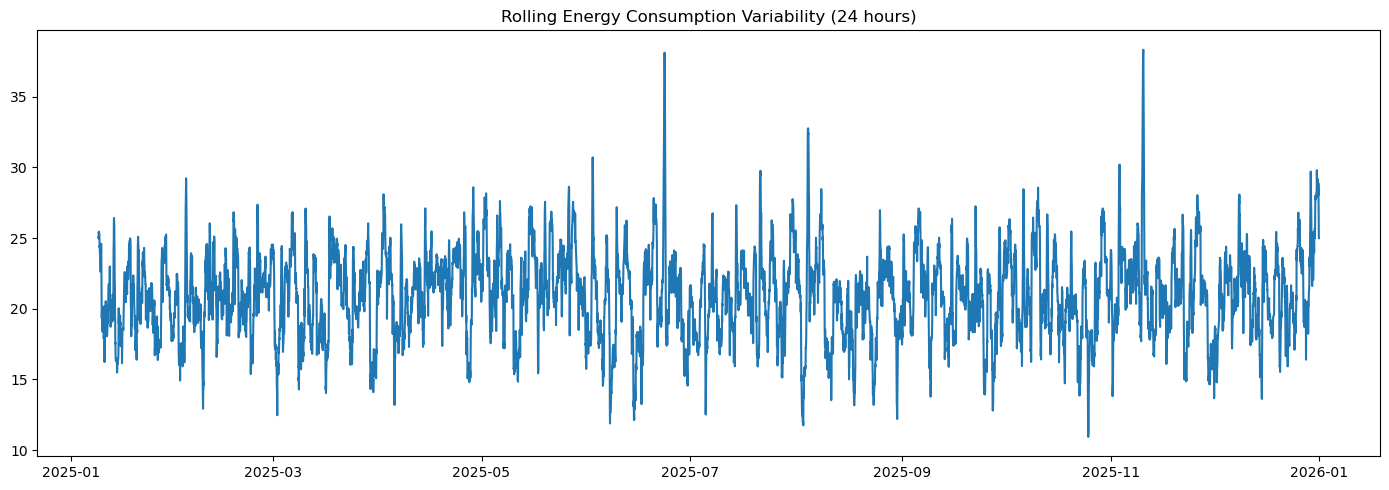

In [6]:
# 3.4 Rolling mean and std
df["rolling_mean_24"]  = df["energy_kwh"].rolling(window=24).mean()
df["rolling_mean_168"] = df["energy_kwh"].rolling(window=168).mean()

plt.figure(figsize=(14, 6))
plt.plot(df["energy_kwh"],        alpha=0.3, label="Actual")
plt.plot(df["rolling_mean_24"],   label="24-hour Rolling Mean")
plt.plot(df["rolling_mean_168"],  label="Weekly Rolling Mean")
plt.legend()
plt.title("Rolling Energy Consumption Trends")
plt.tight_layout()
plt.show()

df["rolling_std_24"] = df["energy_kwh"].rolling(window=24).std()
plt.figure(figsize=(14, 5))
plt.plot(df["rolling_std_24"])
plt.title("Rolling Energy Consumption Variability (24 hours)")
plt.tight_layout()
plt.show()

4. Time Series Diagnostics

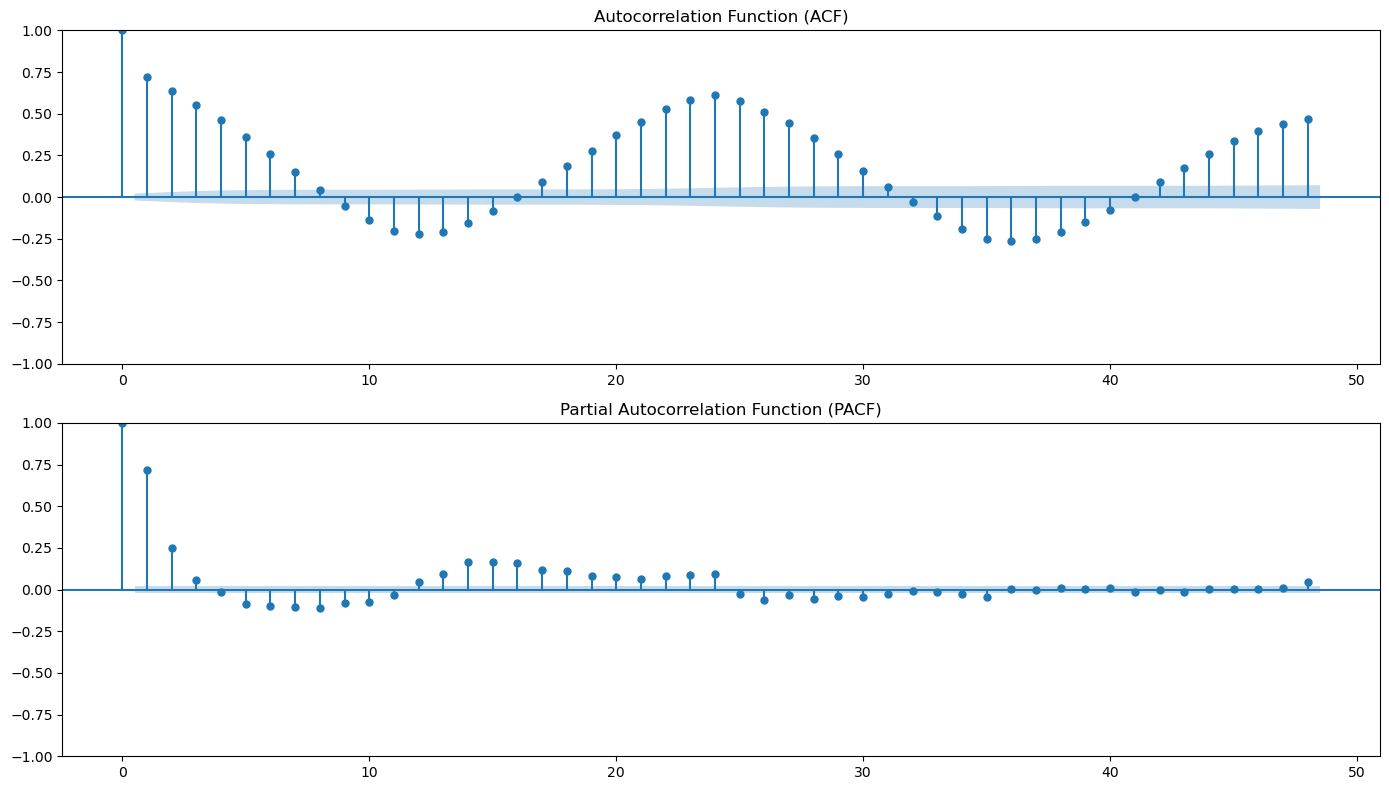

In [7]:
# 4.1 ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(df["energy_kwh"],  lags=48, ax=axes[0], title="Autocorrelation Function (ACF)")
plot_pacf(df["energy_kwh"], lags=48, ax=axes[1], title="Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

In [8]:
# 4.2 ADF Stationarity Test
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["energy_kwh"])
print("=== Augmented Dickey-Fuller Test ===")
print(f"ADF Statistic : {result[0]:.6f}")
print(f"p-value       : {result[1]:.2e}")
print(f"Critical Values:")
for key, val in result[4].items():
    print(f"   {key}: {val:.4f}")
if result[1] < 0.05:
    print("\nConclusion: Series is STATIONARY (reject null hypothesis)")
else:
    print("\nConclusion: Series is NON-STATIONARY (fail to reject null hypothesis)")

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -9.351793
p-value       : 8.26e-16
Critical Values:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669

Conclusion: Series is STATIONARY (reject null hypothesis)


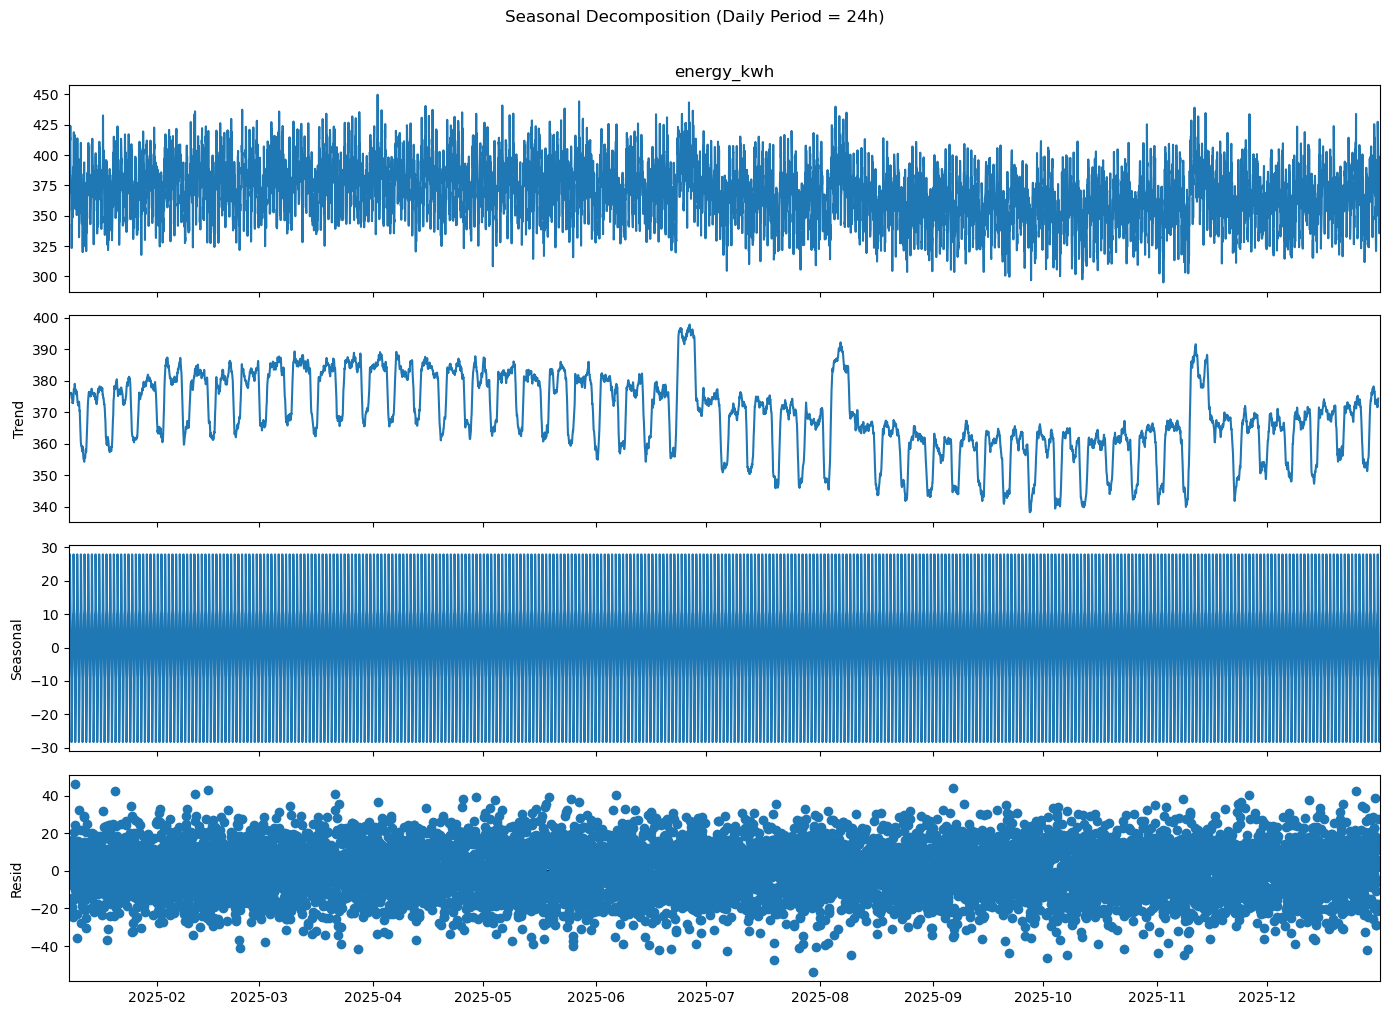

In [9]:
# 4.3 Seasonal Decomposition - Daily (period=24)
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df["energy_kwh"], model="additive", period=24)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Seasonal Decomposition (Daily Period = 24h)", y=1.01)
plt.tight_layout()
plt.show()

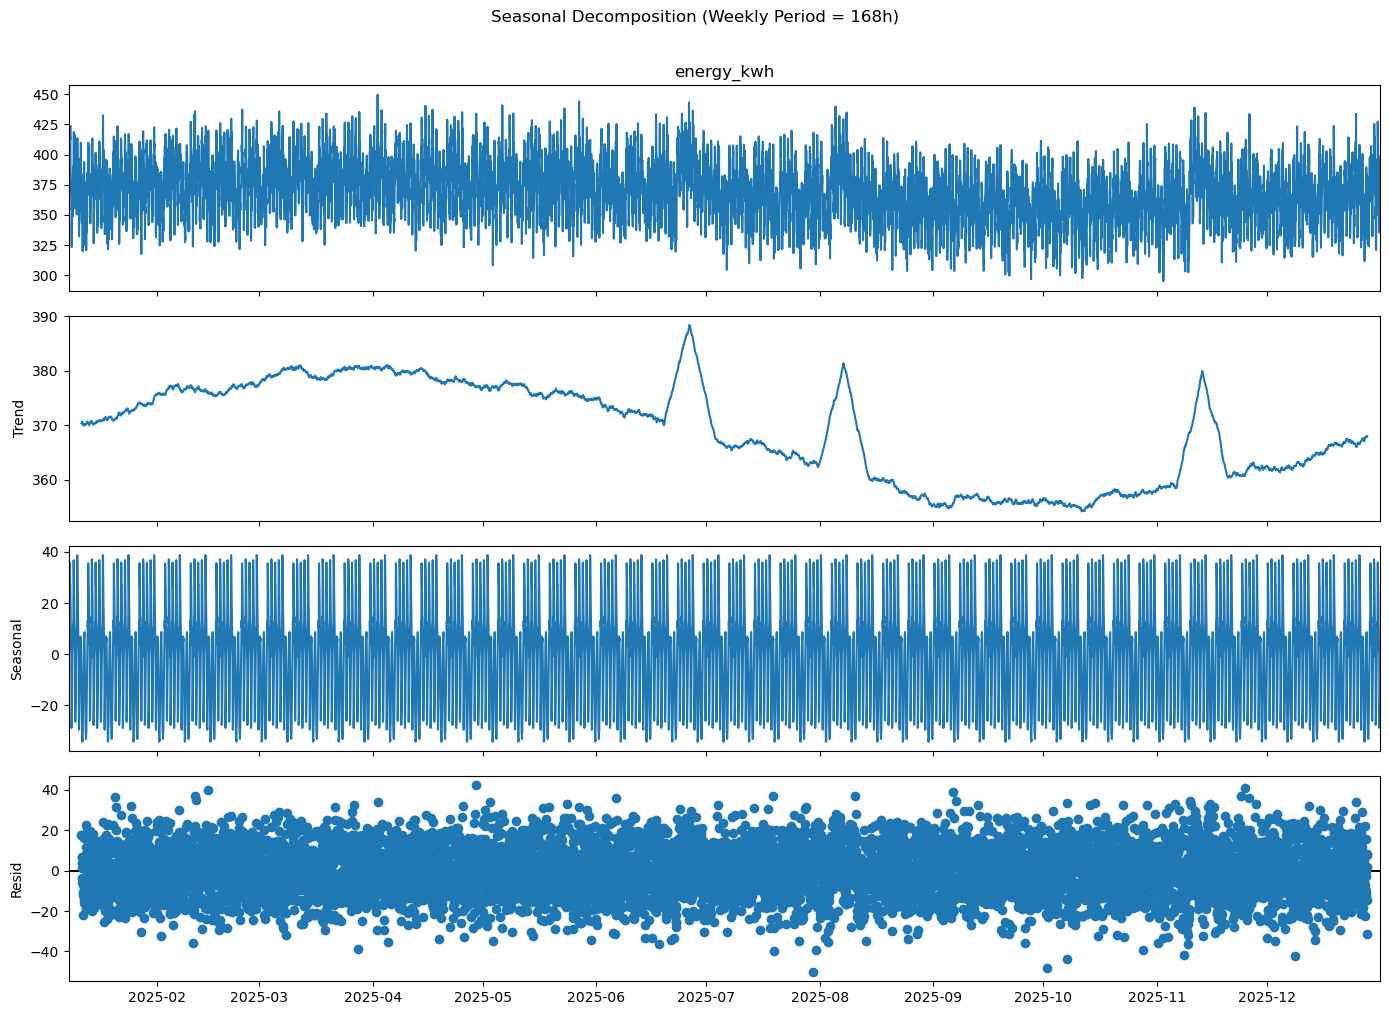

In [10]:
# 4.4 Seasonal Decomposition - Weekly (period=168)
decomposition_week = seasonal_decompose(df["energy_kwh"], model="additive", period=168)
fig = decomposition_week.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Seasonal Decomposition (Weekly Period = 168h)", y=1.01)
plt.tight_layout()
plt.show()

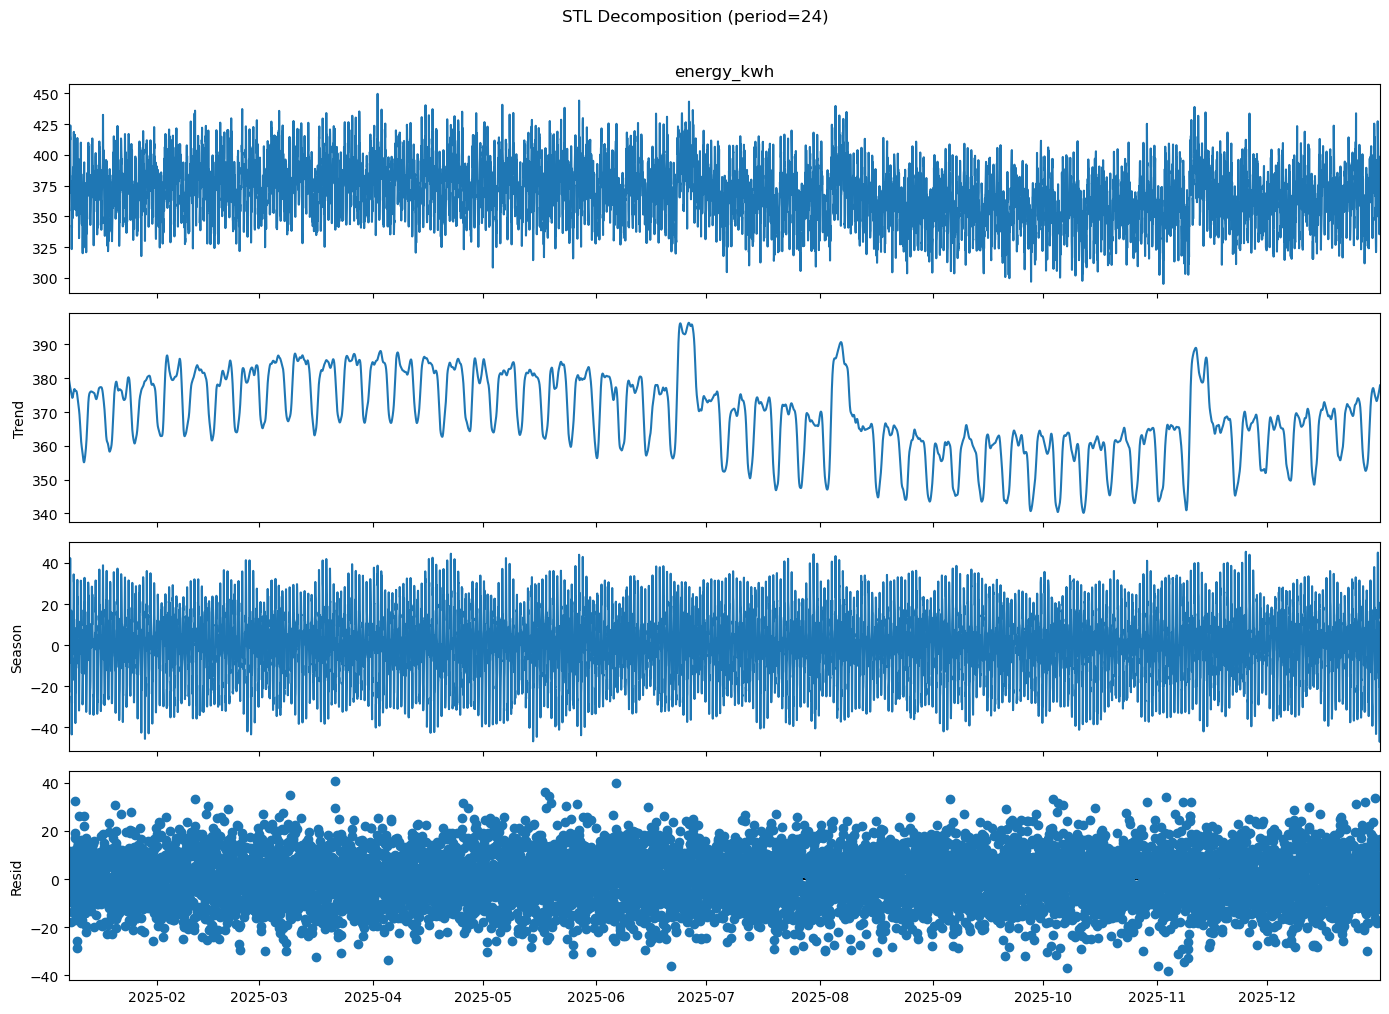

In [11]:
# 4.5 STL Decomposition
from statsmodels.tsa.seasonal import STL

stl    = STL(df["energy_kwh"], period=24)
result_stl = stl.fit()
fig    = result_stl.plot()
fig.set_size_inches(14, 10)
fig.suptitle("STL Decomposition (period=24)", y=1.01)
plt.tight_layout()
plt.show()

 5. Multicollinearity Diagnostics — Variance Inflation Factor (VIF)

=== Variance Inflation Factor (VIF) ===
    Feature       VIF
   humidity 88.785944
temperature 53.273376
 wind_speed 20.239033
day_of_week  8.642519
      month  7.520145
       hour  6.459096
  occupancy  5.199151
 is_weekend  4.384623
  exam_week  1.081488

Interpretation: VIF > 10 indicates HIGH multicollinearity


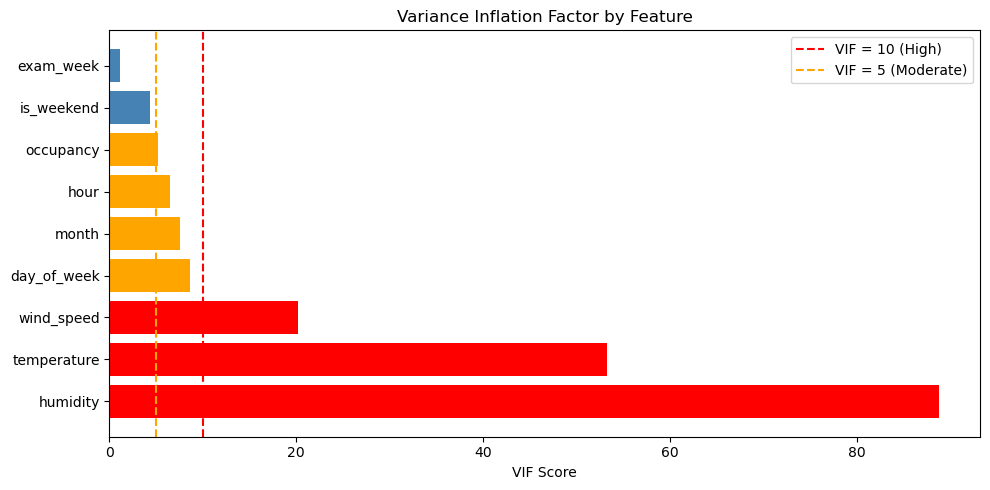

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use only the original feature columns (not lag/rolling/cyclical derived ones)
vif_features = ["temperature", "humidity", "wind_speed", "occupancy",
                "exam_week", "hour", "day_of_week", "month", "is_weekend"]

vif_df = df[vif_features].dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = vif_features
vif_data["VIF"]     = [variance_inflation_factor(vif_df.values, i)
                        for i in range(vif_df.shape[1])]
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

print("=== Variance Inflation Factor (VIF) ===")
print(vif_data.to_string(index=False))
print()
print("Interpretation: VIF > 10 indicates HIGH multicollinearity")

plt.figure(figsize=(10, 5))
colors = ["red" if v > 10 else "orange" if v > 5 else "steelblue"
          for v in vif_data["VIF"]]
plt.barh(vif_data["Feature"], vif_data["VIF"], color=colors)
plt.axvline(x=10, color="red",    linestyle="--", label="VIF = 10 (High)")
plt.axvline(x=5,  color="orange", linestyle="--", label="VIF = 5 (Moderate)")
plt.xlabel("VIF Score")
plt.title("Variance Inflation Factor by Feature")
plt.legend()
plt.tight_layout()
plt.show()

6. Outlier Detection

Number of outliers detected (|Z| > 3): 5


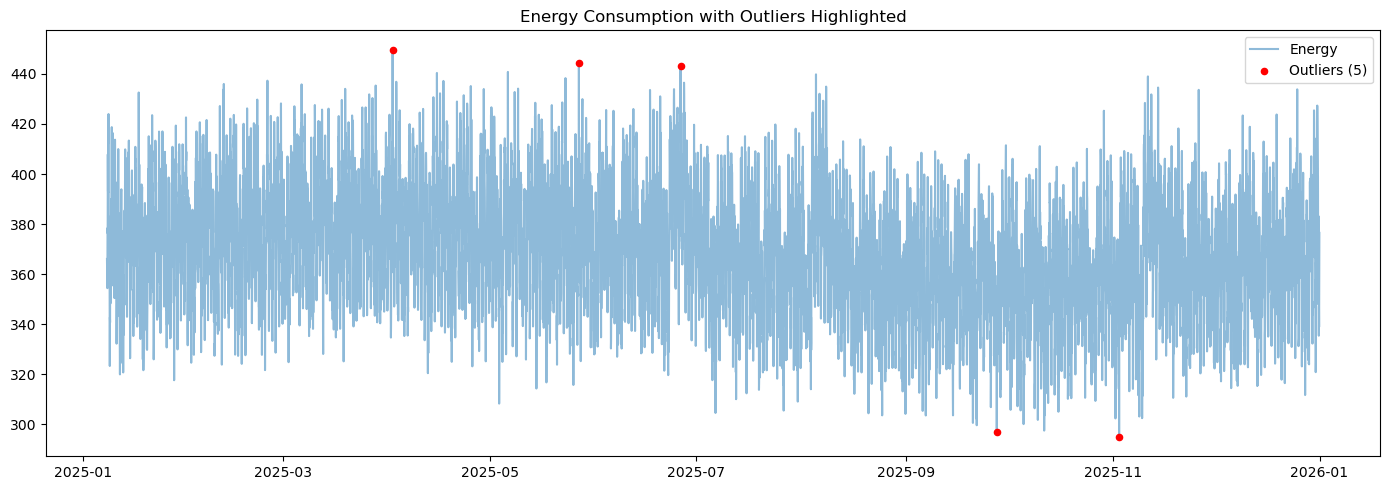

<Figure size 1600x500 with 0 Axes>

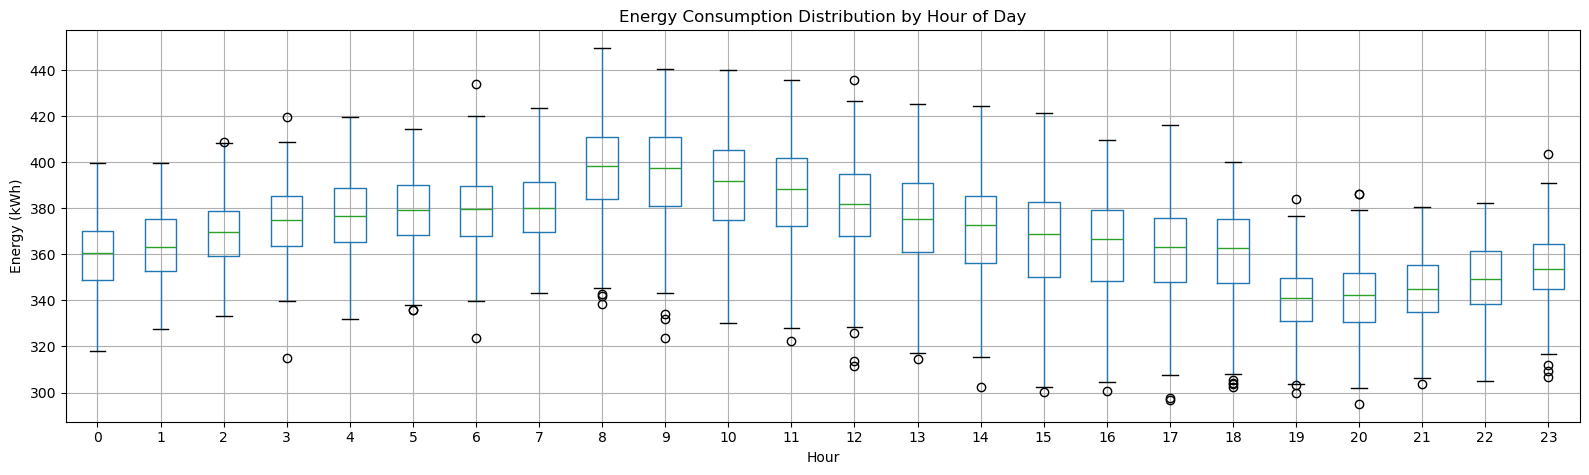

In [13]:
# Z-score based outlier detection
from scipy import stats

z_scores = np.abs(stats.zscore(df["energy_kwh"]))
outliers = df[z_scores > 3]
print(f"Number of outliers detected (|Z| > 3): {len(outliers)}")

plt.figure(figsize=(14, 5))
plt.plot(df["energy_kwh"], alpha=0.5, label="Energy")
plt.scatter(outliers.index, outliers["energy_kwh"],
            color="red", zorder=5, label=f"Outliers ({len(outliers)})", s=20)
plt.title("Energy Consumption with Outliers Highlighted")
plt.legend()
plt.tight_layout()
plt.show()

# Boxplot by hour
plt.figure(figsize=(16, 5))
df.boxplot(column="energy_kwh", by="hour", figsize=(16, 5))
plt.suptitle("")
plt.title("Energy Consumption Distribution by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Energy (kWh)")
plt.tight_layout()
plt.show()

7. Train / Test Split (80 / 20)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score

# Re-compute rolling cols correctly (shift already applied above)
df["rolling_mean_24"]  = df["energy_kwh"].shift(1).rolling(window=24).mean()
df["rolling_std_24"]   = df["energy_kwh"].shift(1).rolling(window=24).std()
df["rolling_mean_168"] = df["energy_kwh"].shift(1).rolling(window=168).mean()
df = df.dropna()

train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test  = df.iloc[train_size:]

X_train = train.drop("energy_kwh", axis=1)
y_train = train["energy_kwh"]
X_test  = test.drop("energy_kwh", axis=1)
y_test  = test["energy_kwh"]

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 6739
Test samples     : 1685


8. Evaluation Helper Functions

In [15]:
def adjusted_r2(r2, n, k):
    """Adjusted R² = 1 - (1-R²)*(n-1)/(n-k-1)"""
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate(name, y_true, y_pred, n_features):
    n   = len(y_true)
    r2  = r2_score(y_true, y_pred)
    adj = adjusted_r2(r2, n, n_features)
    mae_  = mean_absolute_error(y_true, y_pred)
    rmse_ = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_ = mape(y_true, y_pred)
    print(f"\n{name}")
    print(f"  R²          : {r2:.4f}")
    print(f"  Adjusted R² : {adj:.4f}")
    print(f"  MAE         : {mae_:.4f}")
    print(f"  RMSE        : {rmse_:.4f}")
    print(f"  MAPE        : {mape_:.2f}%")
    return {"Model": name, "R2": round(r2,4), "Adj_R2": round(adj,4),
            "MAE": round(mae_,4), "RMSE": round(rmse_,4), "MAPE": round(mape_,2)}

n_feat = X_train.shape[1]
all_results = []

9. Naive Baseline Model

In [16]:
naive_pred     = y_test.shift(1).dropna()
y_test_naive   = y_test.iloc[1:]

res = evaluate("Naive Baseline", y_test_naive, naive_pred, n_feat)
all_results.append(res)


Naive Baseline
  R²          : 0.3818
  Adjusted R² : 0.3748
  MAE         : 14.4984
  RMSE        : 18.3576
  MAPE        : 4.00%


10. Ridge Regression with GridSearchCV + TimeSeriesSplit

In [17]:
tscv = TimeSeriesSplit(n_splits=5)

ridge_params = {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_gs     = GridSearchCV(Ridge(), ridge_params, cv=tscv,
                            scoring="neg_mean_squared_error", n_jobs=-1)
ridge_gs.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_gs.best_params_)
ridge_best = ridge_gs.best_estimator_
ridge_pred = ridge_best.predict(X_test)

res = evaluate("Ridge Regression", y_test, ridge_pred, n_feat)
all_results.append(res)

Best Ridge alpha: {'alpha': 0.1}

Ridge Regression
  R²          : 0.8094
  Adjusted R² : 0.8073
  MAE         : 8.1020
  RMSE        : 10.1925
  MAPE        : 2.24%


11. Lasso Regression with GridSearchCV + TimeSeriesSplit

In [18]:
lasso_params = {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0]}
lasso_gs     = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=tscv,
                            scoring="neg_mean_squared_error", n_jobs=-1)
lasso_gs.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_gs.best_params_)
lasso_best = lasso_gs.best_estimator_
lasso_pred = lasso_best.predict(X_test)

res = evaluate("Lasso Regression", y_test, lasso_pred, n_feat)
all_results.append(res)

Best Lasso alpha: {'alpha': 0.1}

Lasso Regression
  R²          : 0.8067
  Adjusted R² : 0.8045
  MAE         : 8.1459
  RMSE        : 10.2655
  MAPE        : 2.25%


12. Random Forest with GridSearchCV + TimeSeriesSplit

In [19]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth"   : [5, 10, None]
}
rf_gs = GridSearchCV(RandomForestRegressor(random_state=42), rf_params,
                     cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1)
rf_gs.fit(X_train, y_train)

print("Best RF params:", rf_gs.best_params_)
rf_best = rf_gs.best_estimator_
rf_pred = rf_best.predict(X_test)

res = evaluate("Random Forest", y_test, rf_pred, n_feat)
all_results.append(res)

Best RF params: {'max_depth': 10, 'n_estimators': 200}

Random Forest
  R²          : 0.7866
  Adjusted R² : 0.7842
  MAE         : 8.6213
  RMSE        : 10.7847
  MAPE        : 2.38%


13. Gradient Boosting with GridSearchCV + TimeSeriesSplit

In [20]:
gbr_params = {
    "n_estimators"  : [100, 200],
    "learning_rate" : [0.05, 0.1],
    "max_depth"     : [3, 5]
}
gbr_gs = GridSearchCV(GradientBoostingRegressor(random_state=42), gbr_params,
                      cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1)
gbr_gs.fit(X_train, y_train)

print("Best GBR params:", gbr_gs.best_params_)
gbr_best = gbr_gs.best_estimator_
gbr_pred = gbr_best.predict(X_test)

res = evaluate("Gradient Boosting", y_test, gbr_pred, n_feat)
all_results.append(res)

Best GBR params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}

Gradient Boosting
  R²          : 0.7956
  Adjusted R² : 0.7932
  MAE         : 8.4244
  RMSE        : 10.5567
  MAPE        : 2.32%


14. Model Comparison Table


=== Full Model Comparison ===
            Model     R2  Adj_R2     MAE    RMSE  MAPE
   Naive Baseline 0.3818  0.3748 14.4984 18.3576  4.00
 Ridge Regression 0.8094  0.8073  8.1020 10.1925  2.24
 Lasso Regression 0.8067  0.8045  8.1459 10.2655  2.25
    Random Forest 0.7866  0.7842  8.6213 10.7847  2.38
Gradient Boosting 0.7956  0.7932  8.4244 10.5567  2.32


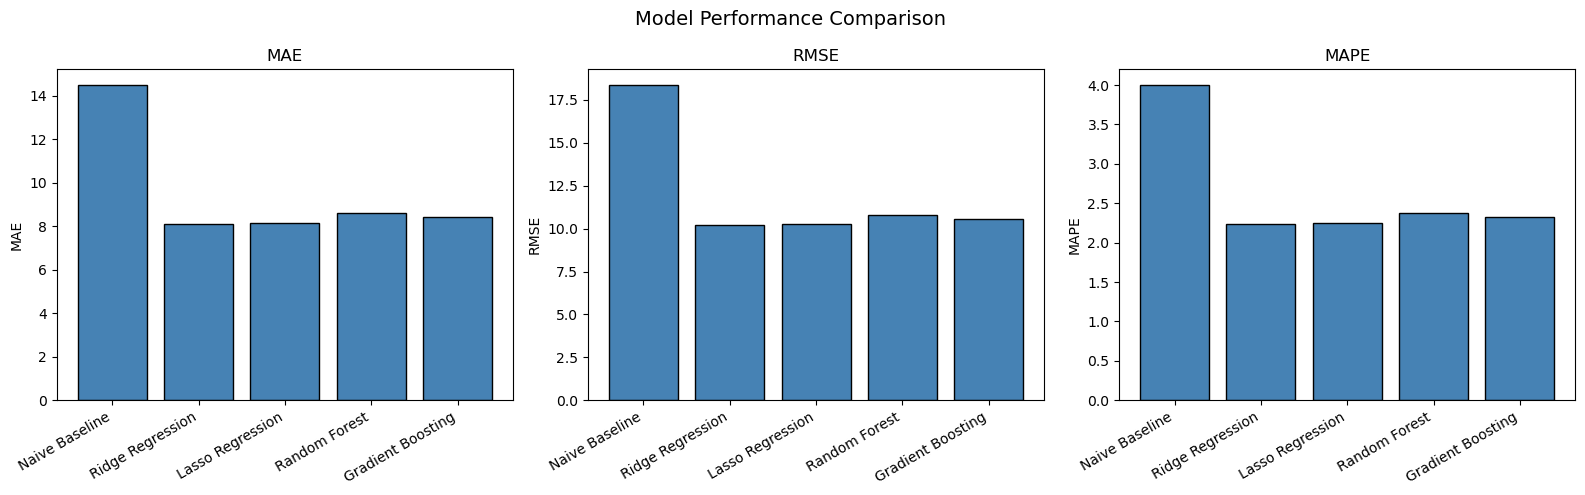

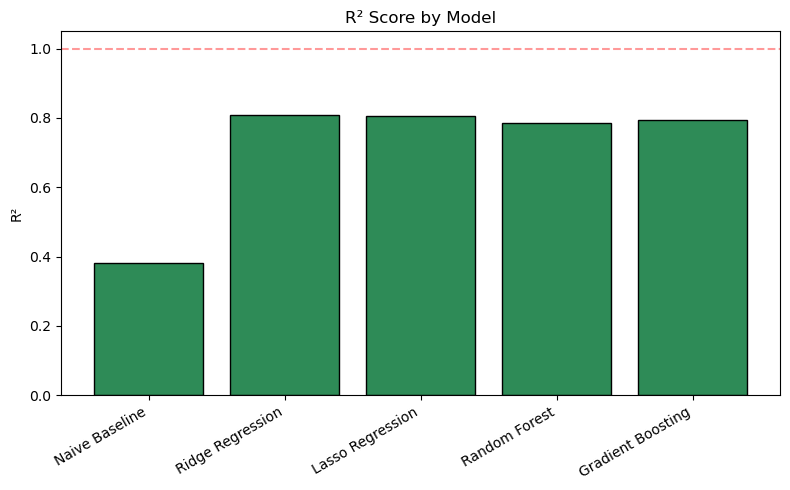

In [21]:
results_df = pd.DataFrame(all_results)
print("\n=== Full Model Comparison ===")
print(results_df.to_string(index=False))

# Bar chart comparison
metrics = ["MAE", "RMSE", "MAPE"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, metrics):
    ax.bar(results_df["Model"], results_df[metric], color="steelblue", edgecolor="black")
    ax.set_title(metric)
    ax.set_xticklabels(results_df["Model"], rotation=30, ha="right")
    ax.set_ylabel(metric)
plt.suptitle("Model Performance Comparison", fontsize=14)
plt.tight_layout()
plt.show()

# R² comparison
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["R2"], color="seagreen", edgecolor="black")
plt.axhline(y=1, color="red", linestyle="--", alpha=0.4)
plt.title("R² Score by Model")
plt.ylabel("R²")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

15. Actual vs Predicted Plots (All Models)

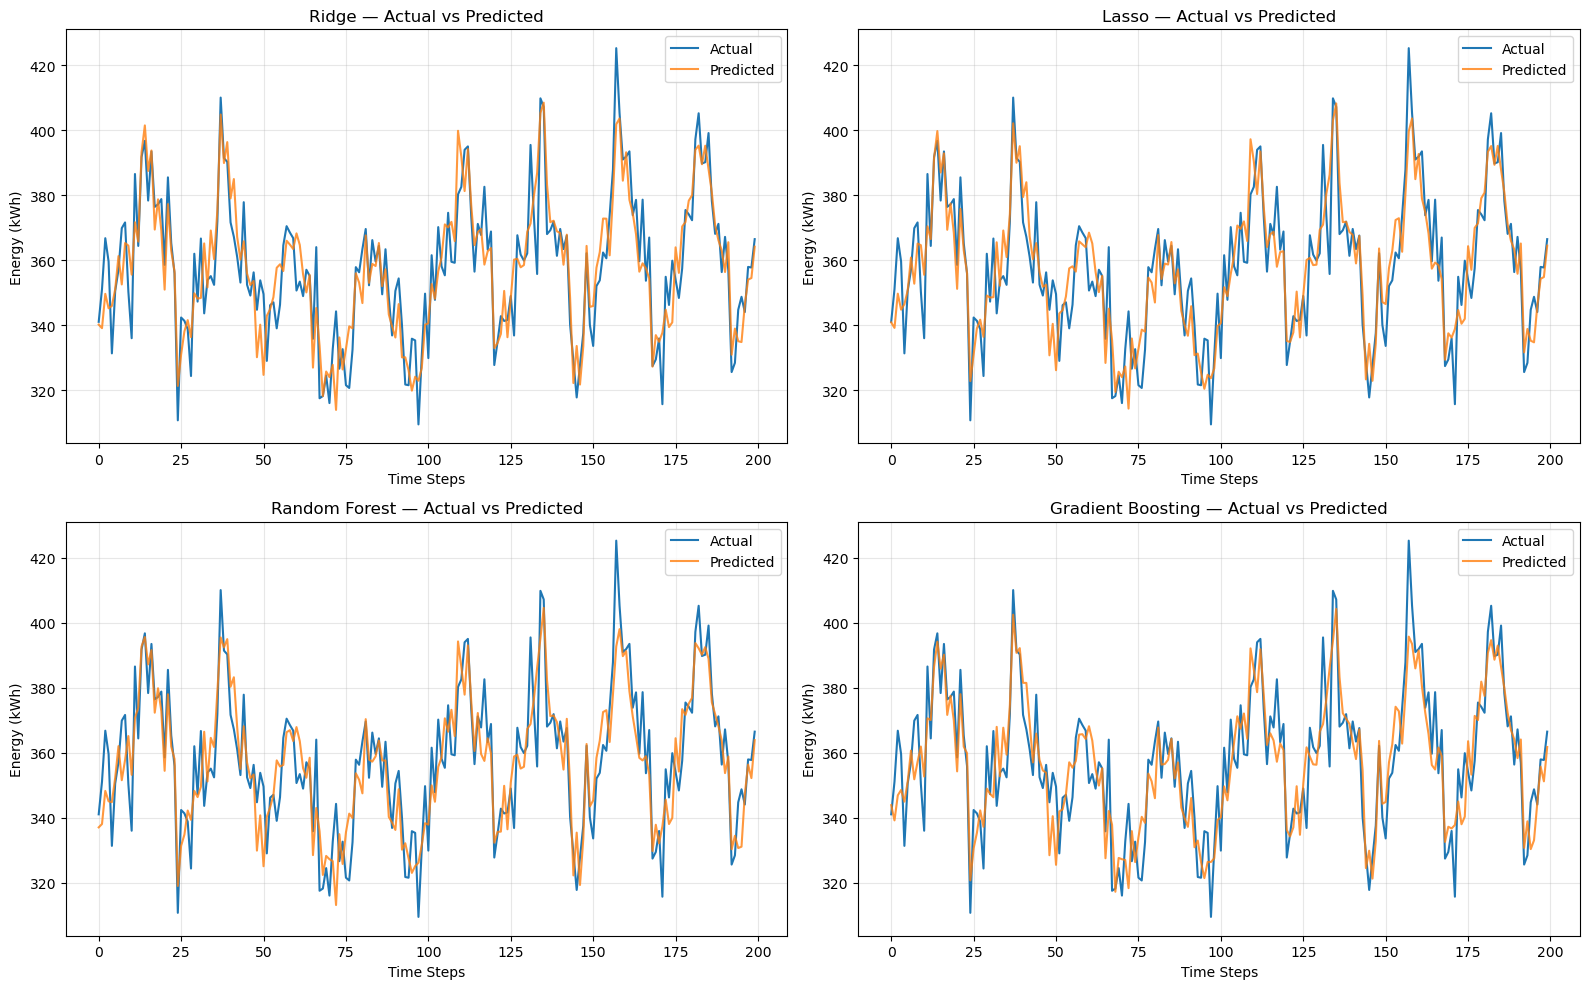

In [22]:
predictions = {
    "Ridge"            : ridge_pred,
    "Lasso"            : lasso_pred,
    "Random Forest"    : rf_pred,
    "Gradient Boosting": gbr_pred,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, predictions.items()):
    ax.plot(y_test.values[:200],  linewidth=1.5, label="Actual")
    ax.plot(pred[:200],           linewidth=1.5, label="Predicted", alpha=0.8)
    ax.set_title(f"{name} — Actual vs Predicted")
    ax.set_xlabel("Time Steps")
    ax.set_ylabel("Energy (kWh)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

16. Residual Diagnostics

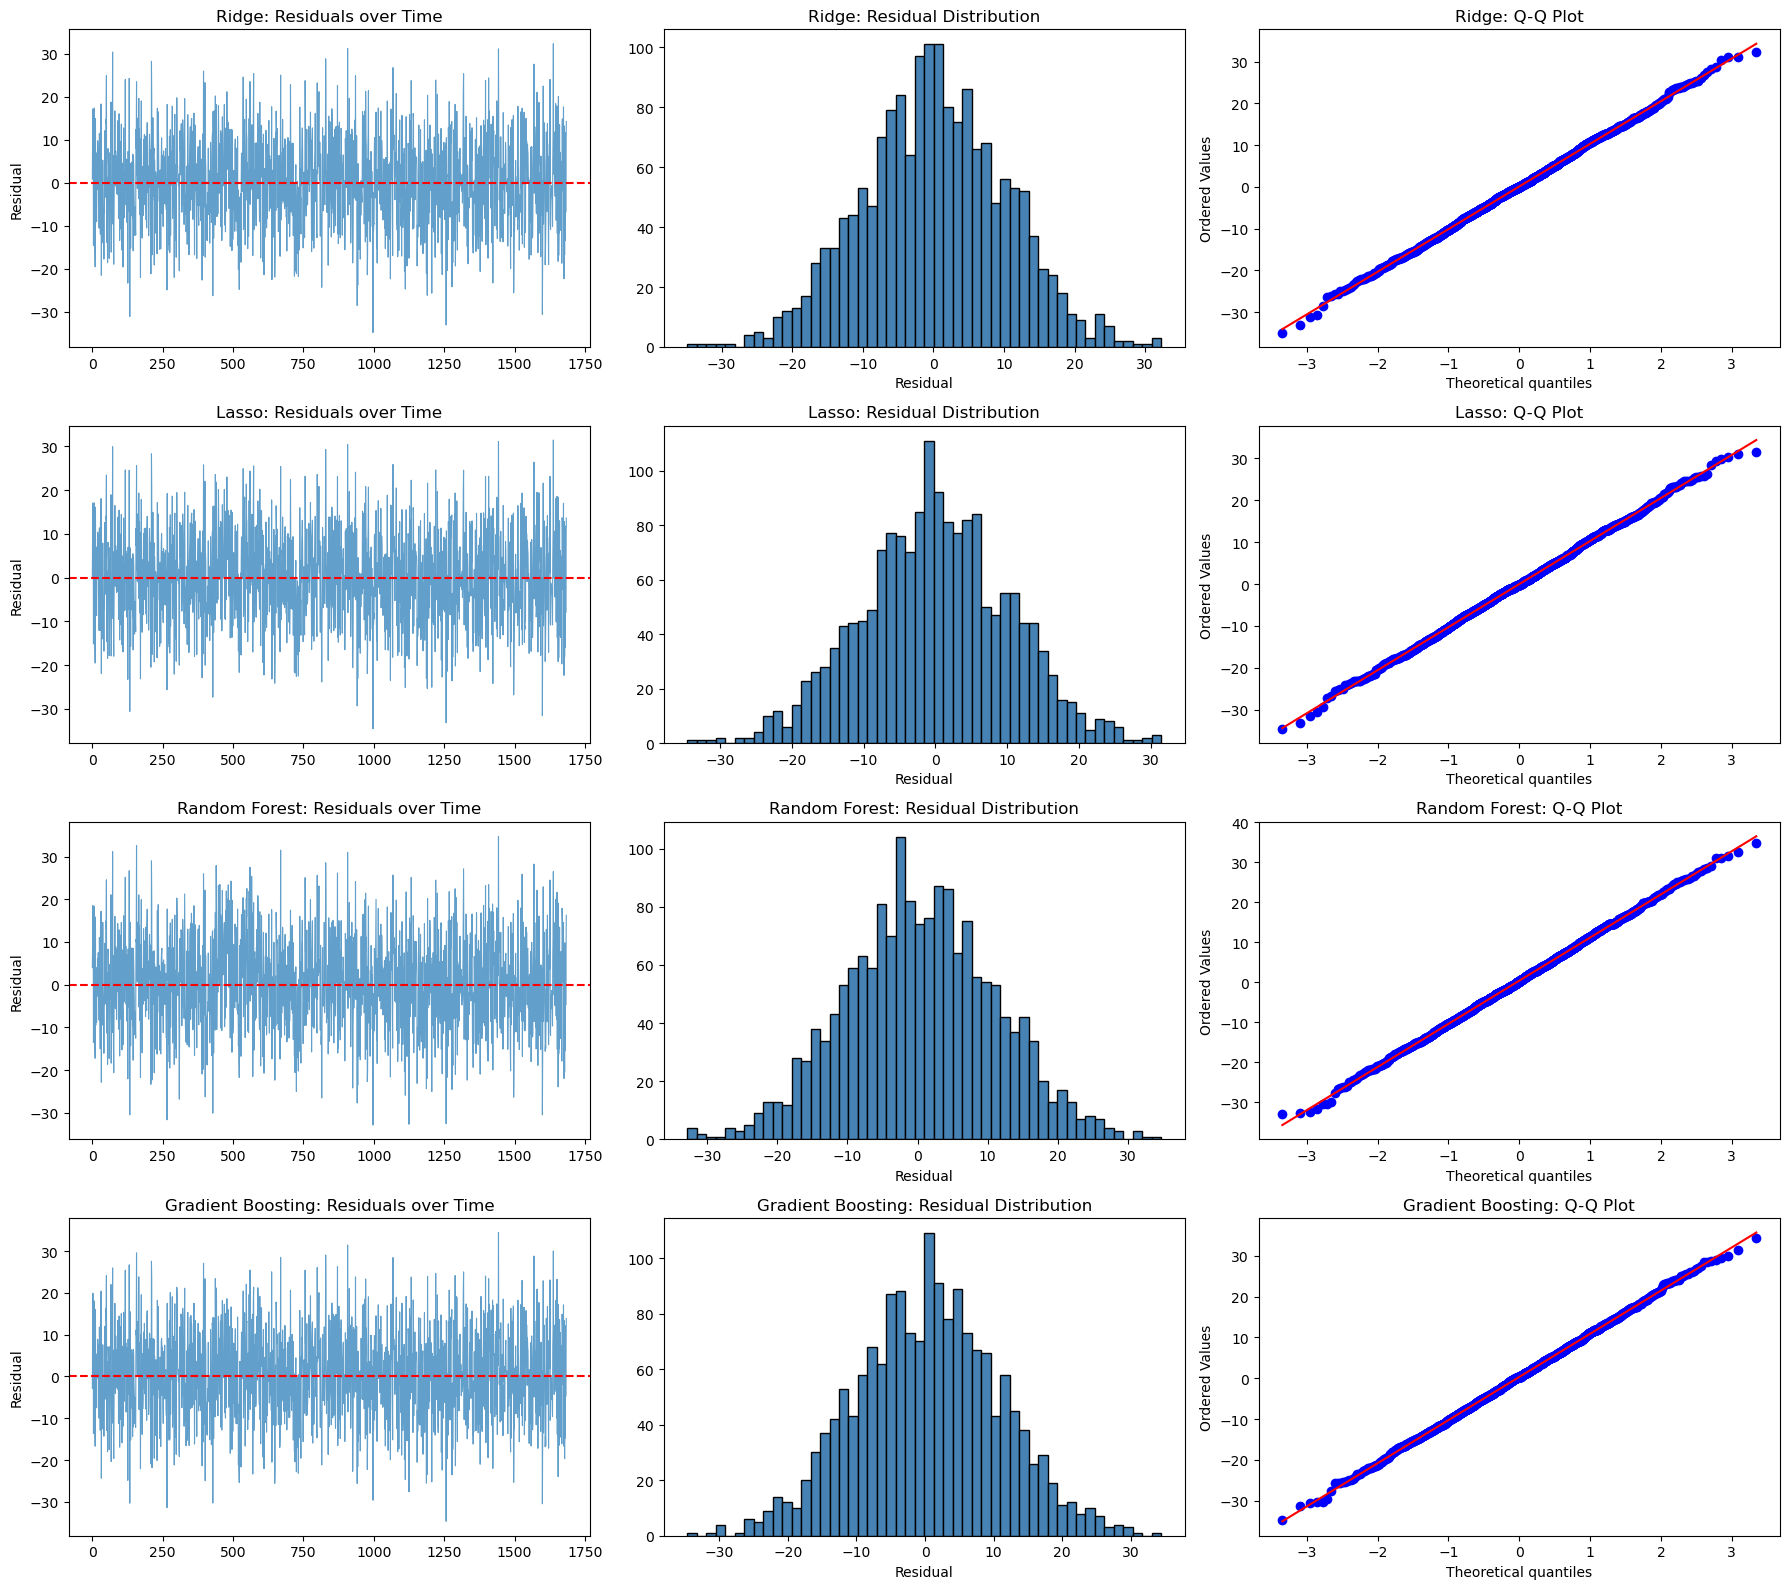

In [23]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(len(predictions), 3, figsize=(18, 4 * len(predictions)))

for row, (name, pred) in enumerate(predictions.items()):
    residuals = y_test.values - pred

    # Residuals over time
    axes[row, 0].plot(residuals, linewidth=0.8, alpha=0.7)
    axes[row, 0].axhline(0, color="red", linestyle="--")
    axes[row, 0].set_title(f"{name}: Residuals over Time")
    axes[row, 0].set_ylabel("Residual")

    # Histogram of residuals
    axes[row, 1].hist(residuals, bins=50, edgecolor="black", color="steelblue")
    axes[row, 1].set_title(f"{name}: Residual Distribution")
    axes[row, 1].set_xlabel("Residual")

    # Q-Q plot
    scipy_stats.probplot(residuals, dist="norm", plot=axes[row, 2])
    axes[row, 2].set_title(f"{name}: Q-Q Plot")

plt.tight_layout()
plt.show()

17. Feature Importance & Coefficient Interpretation

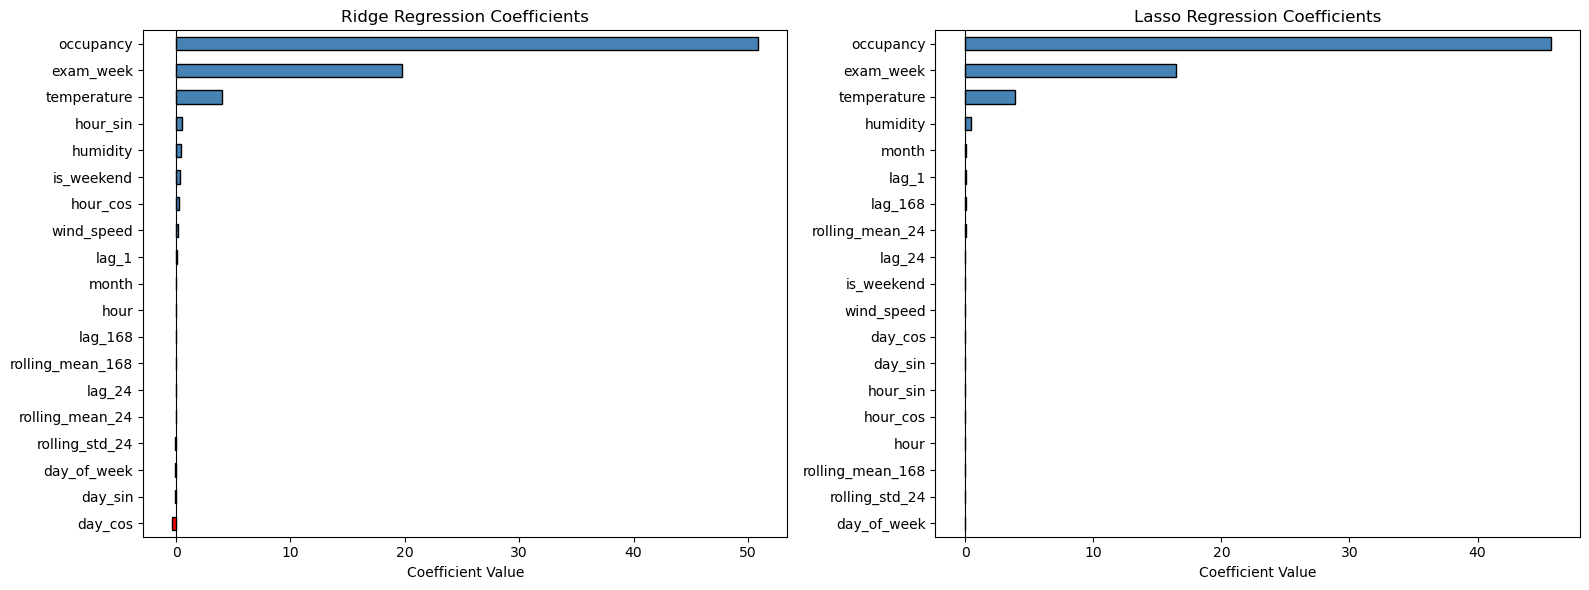

In [24]:
# Ridge and Lasso coefficients
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
feature_names = X_train.columns.tolist()

for ax, (name, model) in zip(axes, [("Ridge", ridge_best), ("Lasso", lasso_best)]):
    coefs = pd.Series(model.coef_, index=feature_names).sort_values()
    colors = ["red" if c < 0 else "steelblue" for c in coefs]
    coefs.plot(kind="barh", ax=ax, color=colors, edgecolor="black")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{name} Regression Coefficients")
    ax.set_xlabel("Coefficient Value")

plt.tight_layout()
plt.show()

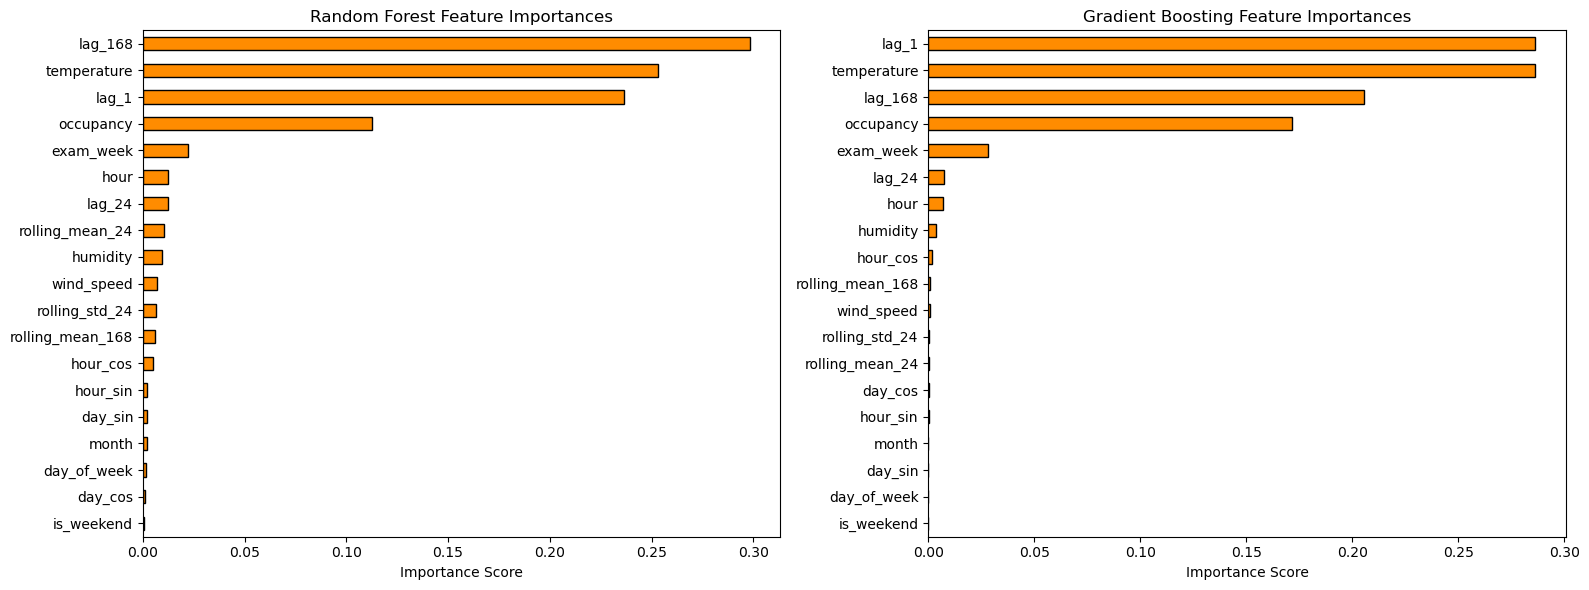

In [25]:
# Random Forest and Gradient Boosting feature importances
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, model) in zip(axes, [("Random Forest", rf_best), ("Gradient Boosting", gbr_best)]):
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=True)
    importances.plot(kind="barh", ax=ax, color="darkorange", edgecolor="black")
    ax.set_title(f"{name} Feature Importances")
    ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

18. Bias-Variance Analysis via TimeSeriesSplit Cross-Validation

In [26]:
models_cv = {
    "Ridge"            : ridge_best,
    "Lasso"            : lasso_best,
    "Random Forest"    : rf_best,
    "Gradient Boosting": gbr_best,
}

cv_results = {}

for name, model in models_cv.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1)
    rmse_folds = np.sqrt(-scores)
    cv_results[name] = rmse_folds
    print(f"{name}:")
    print(f"  CV RMSE per fold : {np.round(rmse_folds, 3)}")
    print(f"  Mean RMSE        : {rmse_folds.mean():.4f}")
    print(f"  Std  RMSE (Var)  : {rmse_folds.std():.4f}")
    print()

Ridge:
  CV RMSE per fold : [ 9.501 10.414 12.612 10.049 10.056]
  Mean RMSE        : 10.5264
  Std  RMSE (Var)  : 1.0830

Lasso:
  CV RMSE per fold : [ 9.509 10.356 12.492 10.136 10.045]
  Mean RMSE        : 10.5075
  Std  RMSE (Var)  : 1.0304

Random Forest:
  CV RMSE per fold : [10.515 11.008 13.004 11.276 10.624]
  Mean RMSE        : 11.2853
  Std  RMSE (Var)  : 0.9013

Gradient Boosting:
  CV RMSE per fold : [10.39  10.845 13.049 10.598 10.498]
  Mean RMSE        : 11.0759
  Std  RMSE (Var)  : 0.9980



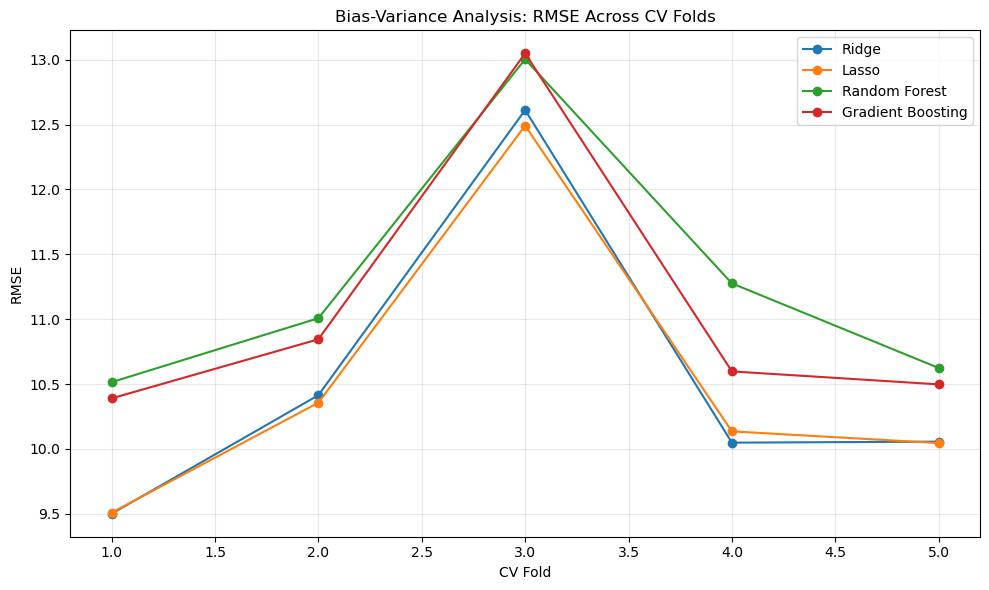

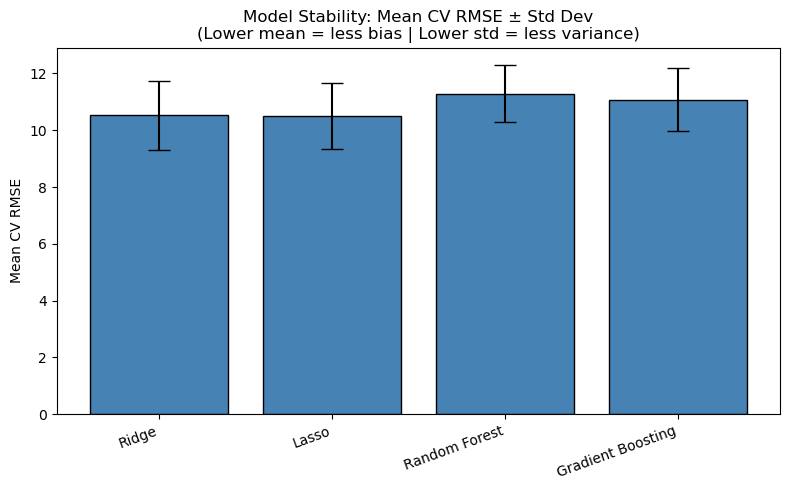

In [27]:
# Bias-variance plot
cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(10, 6))
for col in cv_df.columns:
    plt.plot(range(1, 6), cv_df[col], marker="o", label=col)
plt.xlabel("CV Fold")
plt.ylabel("RMSE")
plt.title("Bias-Variance Analysis: RMSE Across CV Folds")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mean ± Std bar chart
means = cv_df.mean()
stds  = cv_df.std()

plt.figure(figsize=(8, 5))
plt.bar(means.index, means.values, yerr=stds.values,
        color="steelblue", edgecolor="black", capsize=8)
plt.ylabel("Mean CV RMSE")
plt.title("Model Stability: Mean CV RMSE ± Std Dev\n(Lower mean = less bias | Lower std = less variance)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

19. Final Summary

In [28]:
print("=" * 60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(results_df.to_string(index=False))

print("\n" + "=" * 60)
print("CROSS-VALIDATION STABILITY SUMMARY")
print("=" * 60)
for name, scores in cv_results.items():
    print(f"{name:20s}  Mean RMSE: {scores.mean():.4f}  Std: {scores.std():.4f}")

best_model = results_df.loc[results_df["RMSE"].idxmin(), "Model"]
print(f"\nBest model by RMSE on test set: {best_model}")

FINAL MODEL PERFORMANCE SUMMARY
            Model     R2  Adj_R2     MAE    RMSE  MAPE
   Naive Baseline 0.3818  0.3748 14.4984 18.3576  4.00
 Ridge Regression 0.8094  0.8073  8.1020 10.1925  2.24
 Lasso Regression 0.8067  0.8045  8.1459 10.2655  2.25
    Random Forest 0.7866  0.7842  8.6213 10.7847  2.38
Gradient Boosting 0.7956  0.7932  8.4244 10.5567  2.32

CROSS-VALIDATION STABILITY SUMMARY
Ridge                 Mean RMSE: 10.5264  Std: 1.0830
Lasso                 Mean RMSE: 10.5075  Std: 1.0304
Random Forest         Mean RMSE: 11.2853  Std: 0.9013
Gradient Boosting     Mean RMSE: 11.0759  Std: 0.9980

Best model by RMSE on test set: Ridge Regression
